<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(train_imgs, train_labels), (test_imgs, test_labels) = tf.keras.datasets.cifar10.load_data()

train_imgs = train_imgs / 255.0
test_imgs = test_imgs / 255.

class_labels = ['airplanes', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


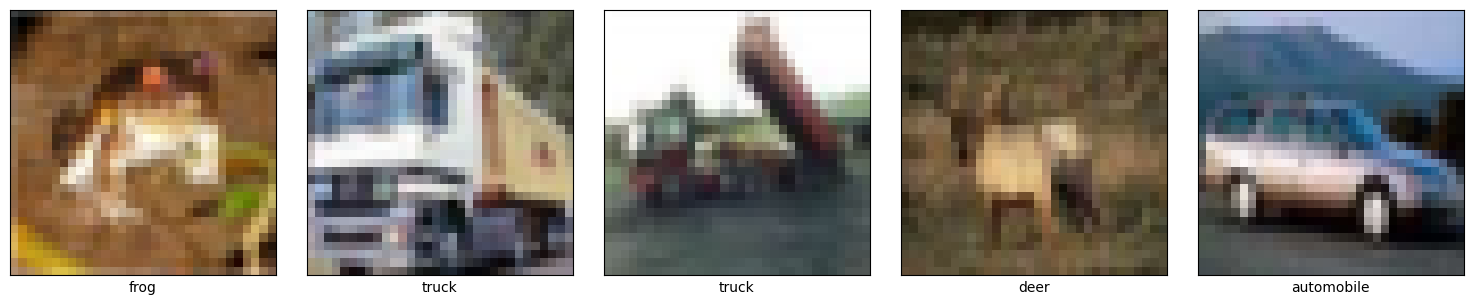

In [ ]:
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_imgs[i])
    plt.xlabel(class_labels[train_labels[i][0]])
plt.tight_layout()
plt.show()

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_imgs, train_labels, epochs=10, validation_data=(test_imgs, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.3600 - loss: 1.7348 - val_accuracy: 0.5656 - val_loss: 1.2192
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5829 - loss: 1.1751 - val_accuracy: 0.6150 - val_loss: 1.0754
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6497 - loss: 1.0015 - val_accuracy: 0.6665 - val_loss: 0.9689
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6872 - loss: 0.8949 - val_accuracy: 0.6687 - val_loss: 0.9426
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7176 - loss: 0.8026 - val_accuracy: 0.6900 - val_loss: 0.9014
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7350 - loss: 0.7505 - val_accuracy: 0.7090 - val_loss: 0.8458
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7605 - loss: 0.6820 - val_accuracy: 0.7050 - val_loss: 0.8720
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7705 - loss: 0.6463 -

In [ ]:
test_loss, test_acc = model.evaluate(test_imgs, test_labels)
print(f"Test Accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7155 - loss: 0.8672
Test Accuracy: 0.7111999988555908


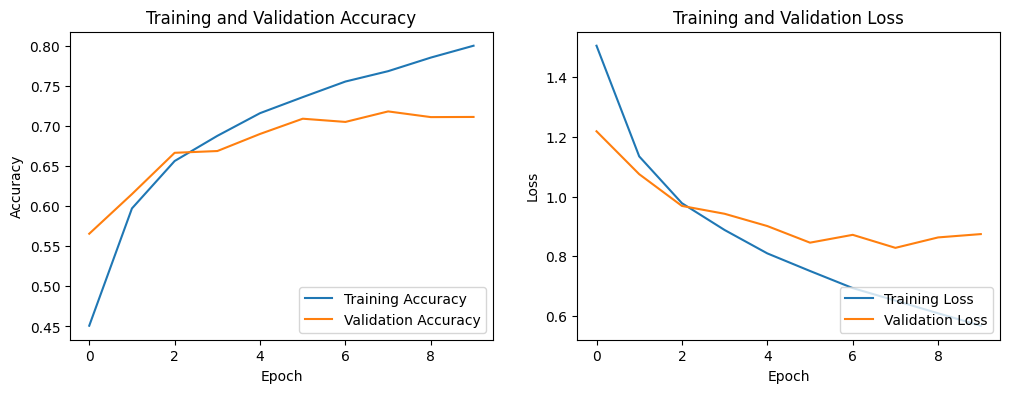

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

plt.show()

In [ ]:
predictions = model.predict(test_imgs[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step


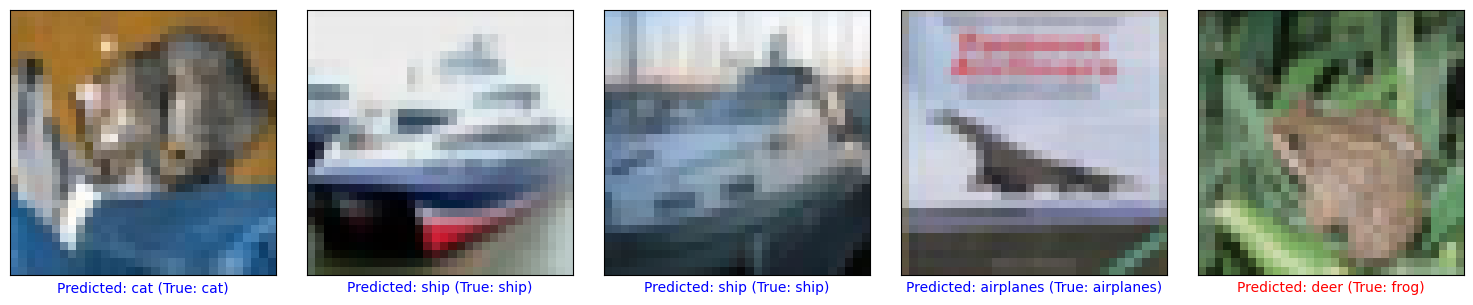

In [ ]:
def plot_img(i, predictions_array, true_labels, imgs, class_labels):
  predictions_array, true_label, img = predictions_array[i], true_labels[i], imgs[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(img)

  predicted_label = np.argmax(predictions_array)

  color = 'blue' if predicted_label == true_label else 'red'

  plt.xlabel(f"Predicted: {class_labels[predicted_label]} (True: {class_labels[true_label[0]]})", color=color)

plt.figure(figsize=(15, 3))

for i in range(5):
  plt.subplot(1, 5, i+1)
  plot_img(i, predictions, test_labels, test_imgs, class_labels)

plt.tight_layout()
plt.show()

# Task 1

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,538 (2.54 MB)

 Trainable params: 666,538 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.3562 - loss: 1.7317 - val_accuracy: 0.6410 - val_loss: 1.0056
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6589 - loss: 0.9566 - val_accuracy: 0.7139 - val_loss: 0.8224
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7378 - loss: 0.7374 - val_accuracy: 0.7279 - val_loss: 0.7801
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7906 - loss: 0.5993 - val_accuracy: 0.7514 - val_loss: 0.7218
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8263 - loss: 0.4929 - val_accuracy: 0.7658 - val_loss: 0.6935
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8637 - loss: 0.3944 - val_accuracy: 0.7597 - val_loss: 0.7569
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8838 - loss: 0.3253 - val_accuracy: 0.7552 - val_loss: 0.8566
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9087 - loss: 0.2592 -

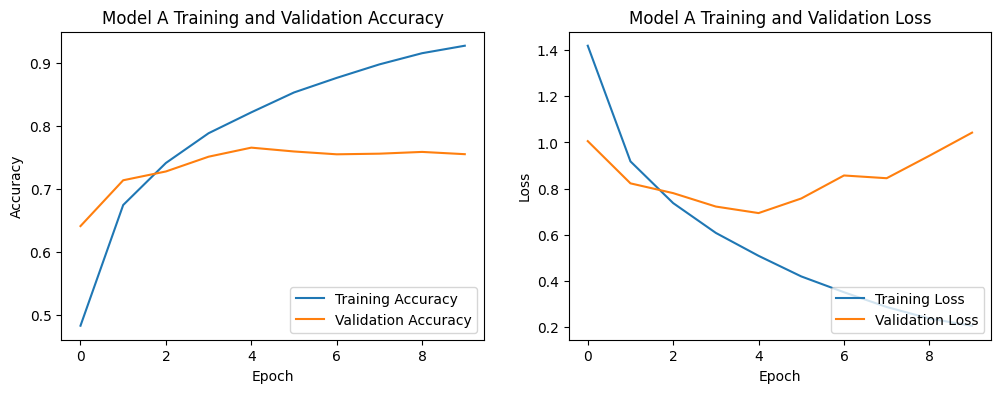

In [ ]:
# Variant A: Bigger filters / more channels (strong baseline)
def build_model_A():
    model = models.Sequential([
        layers.Input((32,32,3)),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model
modelA = build_model_A()
modelA.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modelA.summary()

historyA = modelA.fit(train_imgs, train_labels, epochs=10, validation_data=(test_imgs, test_labels))

test_loss, test_acc = modelA.evaluate(test_imgs, test_labels)
print(f"Model A Test Accuracy: {test_acc}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historyA.history['accuracy'], label='Training Accuracy')
plt.plot(historyA.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model A Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(historyA.history['loss'], label='Training Loss')
plt.plot(historyA.history['val_loss'], label='Validation Loss')
plt.title('Model A Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

plt.show()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 32, 32, 32)     │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 32, 32, 32)     │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 16, 16, 64)     │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 16, 16, 64)     │        37,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 8, 8, 128)      │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,498 (2.55 MB)

 Trainable params: 666,858 (2.54 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.5786 - loss: 1.1897 - val_accuracy: 0.6704 - val_loss: 0.9697
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7283 - loss: 0.7679 - val_accuracy: 0.7078 - val_loss: 0.8463
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7814 - loss: 0.6218 - val_accuracy: 0.7442 - val_loss: 0.7352
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8174 - loss: 0.5225 - val_accuracy: 0.7583 - val_loss: 0.7048
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8446 - loss: 0.4476 - val_accuracy: 0.7823 - val_loss: 0.6459
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8705 - loss: 0.3717 - val_accuracy: 0.7906 - val_loss: 0.6546
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8929 - loss: 0.3071 - val_accuracy: 0.7685 - val_loss: 0.7417
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9096 - loss: 0.2562 -

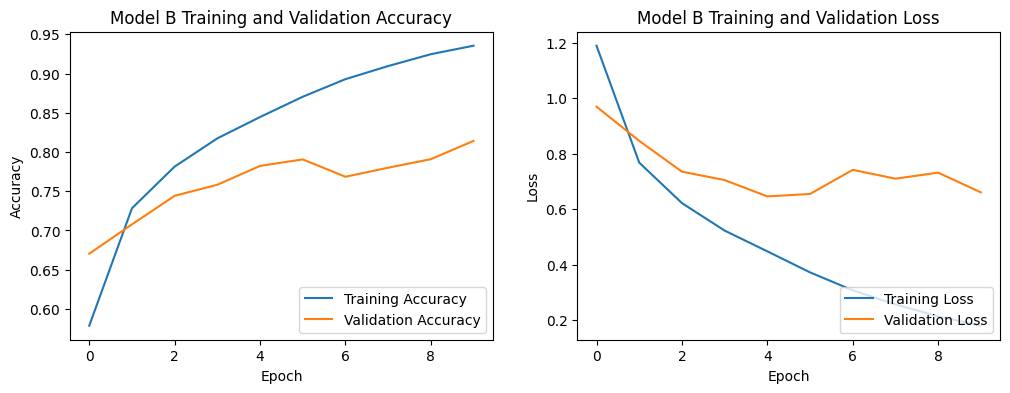

In [6]:
# Variant B: Add BatchNorm (usually improves stability + accuracy)
def conv_bn(filters):
    return models.Sequential([
        layers.Conv2D(filters, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
    ])

def build_model_B():
    inputs = layers.Input((32,32,3))
    x = conv_bn(32)(inputs); x = conv_bn(32)(x); x = layers.MaxPooling2D()(x)
    x = conv_bn(64)(x);      x = conv_bn(64)(x); x = layers.MaxPooling2D()(x)
    x = conv_bn(128)(x);                     x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

modelB = build_model_B()
modelB.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modelB.summary()

historyB = modelB.fit(train_imgs, train_labels, epochs=10, validation_data=(test_imgs, test_labels))

test_loss, test_acc = modelB.evaluate(test_imgs, test_labels)
print(f"Model B Test Accuracy: {test_acc}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historyB.history['accuracy'], label='Training Accuracy')
plt.plot(historyB.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model B Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(historyB.history['loss'], label='Training Loss')
plt.plot(historyB.history['val_loss'], label='Validation Loss')
plt.title('Model B Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

plt.show()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3595 - loss: 1.6959 - val_accuracy: 0.4695 - val_loss: 1.4365
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5024 - loss: 1.3588 - val_accuracy: 0.5610 - val_loss: 1.2082
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5756 - loss: 1.1761 - val_accuracy: 0.5926 - val_loss: 1.1295
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6180 - loss: 1.0660 - val_accuracy: 0.6298 - val_loss: 1.0173
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6510 - loss: 0.9767 - val_accuracy: 0.6510 - val_loss: 0.9816
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6734 - loss: 0.9149 - val_accuracy: 0.6792 - val_loss: 0.9105
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6926 - loss: 0.8640 - val_accuracy: 0.6914 - val_loss: 0.8790
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7111 - loss: 0.8123 

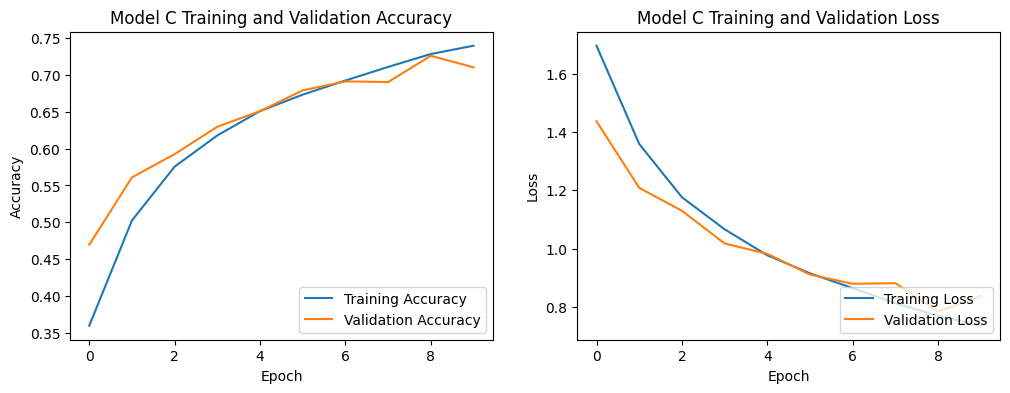

In [7]:
# Variant C: Replace Flatten with GlobalAveragePooling (often reduces overfitting)
def build_model_C():
    inputs = layers.Input((32,32,3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

modelC = build_model_C()
modelC.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modelC.summary()

historyC = modelC.fit(train_imgs, train_labels, epochs=10, validation_data=(test_imgs, test_labels))

test_loss, test_acc = modelC.evaluate(test_imgs, test_labels)
print(f"Model C Test Accuracy: {test_acc}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historyC.history['accuracy'], label='Training Accuracy')
plt.plot(historyC.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model C Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(historyC.history['loss'], label='Training Loss')
plt.plot(historyC.history['val_loss'], label='Validation Loss')
plt.title('Model C Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

plt.show()

# Task 2

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 403,946 (1.54 MB)

 Trainable params: 403,306 (1.54 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.1577 - loss: 2.2327 - val_accuracy: 0.1081 - val_loss: 2.4200 - learning_rate: 0.0500
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2234 - loss: 2.0287 - val_accuracy: 0.3711 - val_loss: 1.7446 - learning_rate: 0.0500
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3897 - loss: 1.6806 - val_accuracy: 0.3627 - val_loss: 1.8500 - learning_rate: 0.0500
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4977 - loss: 1.4116 - val_accuracy: 0.4003 - val_loss: 1.9439 - learning_rate: 0.0500
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5641 - loss: 1.2584 - val_accuracy: 0.5969 - val_loss: 1.1513 - learning_rate: 0.0500
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6062 - loss: 1.1628 - val_accuracy: 0.6277 - val_loss: 1.0783 - learning_rate: 0.0500
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6329 - loss: 1.0889 

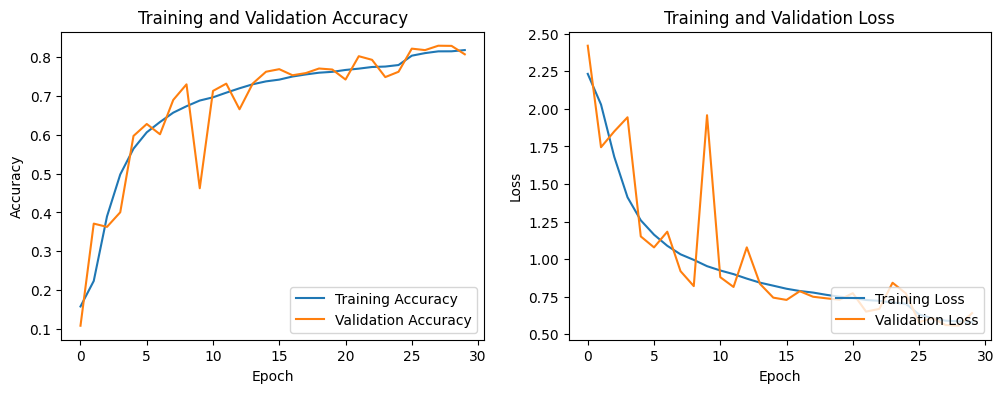

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step


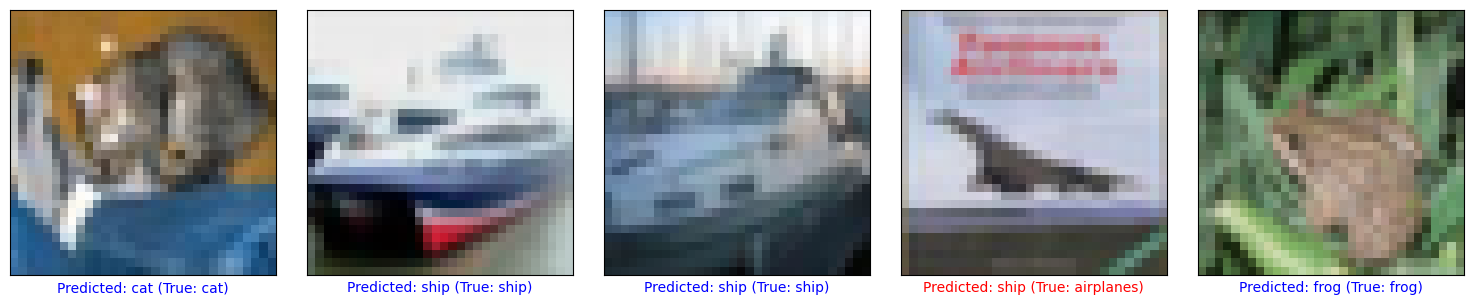

In [5]:
from tensorflow.keras import regularizers
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # ------------------------------------------
    # Improving accuracy
    layers.Conv2D(32, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')

])

# ------------------------------------------
# Improving accuracy - better optimizer setup
opt = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9, nesterov=True)
# ------------------------------------------
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ----------------------------------------------------------
# Improving accuracy - Train a bit longer + LR scheduling
lr_sched = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.5, patience=3, verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=6, restore_best_weights=True, verbose=1)
history = model.fit(train_imgs, train_labels, epochs=30, batch_size=64, validation_data=(test_imgs, test_labels), callbacks=[lr_sched, early_stop])
# ----------------------------------------------------------

test_loss, test_acc = model.evaluate(test_imgs, test_labels)
print(f"Test Accuracy: {test_acc}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

plt.show()

predictions = model.predict(test_imgs[:5])

def plot_img(i, predictions_array, true_labels, imgs, class_labels):
  predictions_array, true_label, img = predictions_array[i], true_labels[i], imgs[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(img)

  predicted_label = np.argmax(predictions_array)

  color = 'blue' if predicted_label == true_label else 'red'

  plt.xlabel(f"Predicted: {class_labels[predicted_label]} (True: {class_labels[true_label[0]]})", color=color)

plt.figure(figsize=(15, 3))

for i in range(5):
  plt.subplot(1, 5, i+1)
  plot_img(i, predictions, test_labels, test_imgs, class_labels)

plt.tight_layout()
plt.show()

# **Task 3 - We will use Variant A since its classic overfitting**

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 4, 4, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,538 (2.54 MB)

 Trainable params: 666,538 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.4504 - loss: 1.5427 - val_accuracy: 0.5901 - val_loss: 1.1858
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6325 - loss: 1.0994 - val_accuracy: 0.6806 - val_loss: 0.9770
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6990 - loss: 0.9371 - val_accuracy: 0.7044 - val_loss: 0.9315
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7418 - loss: 0.8337 - val_accuracy: 0.7384 - val_loss: 0.8686
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7685 - loss: 0.7760 - val_accuracy: 0.7639 - val_loss: 0.8110
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7906 - loss: 0.7233 - val_accuracy: 0.7556 - val_loss: 0.8388
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8102 - loss: 0.6810 - val_accuracy: 0.7815 - val_loss: 0.7921
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8235 - loss: 0.6509 -

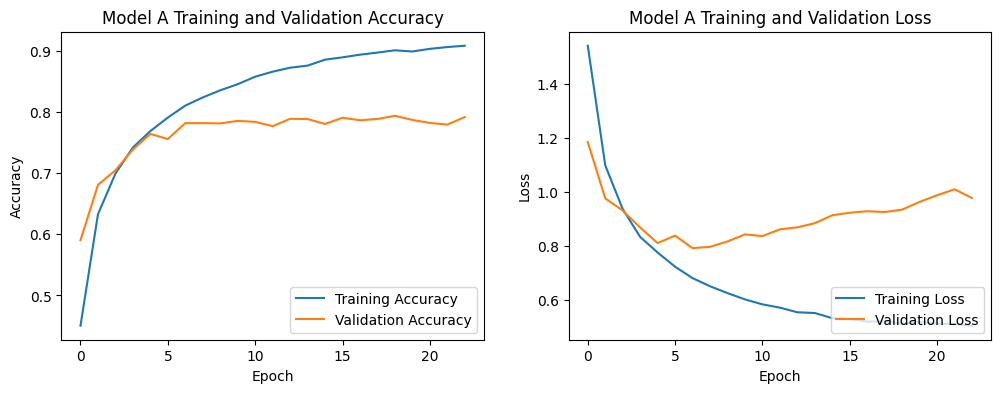

In [9]:
# Variant A: Bigger filters / more channels (strong baseline)
def build_model_A():
    reg = tf.keras.regularizers.L2(1e-4)

    model = models.Sequential([
        layers.Input((32,32,3)),
        # ---------------------------------------------------------
        # L2 weight decay
        layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=reg),
        layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=reg),
        layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D(),
        # --------------------------------------------------------
        # Dropout
        layers.SpatialDropout2D(0.2),
        # --------------------------------------------------------
        layers.Flatten(),
        # L2 weight decay
        layers.Dense(256, activation="relu", kernel_regularizer=reg),
        layers.Dense(10, activation="softmax"),
        # --------------------------------------------------------
        # Dropout
        #layers.Dropout(0.3),
        # --------------------------------------------------------
    ])
    return model

modelA = build_model_A()
modelA.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modelA.summary()

early = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True
)

historyA = modelA.fit(train_imgs, train_labels, epochs=30, validation_data=(test_imgs, test_labels), callbacks=[early])

test_loss, test_acc = modelA.evaluate(test_imgs, test_labels)
print(f"Model A Test Accuracy: {test_acc}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historyA.history['accuracy'], label='Training Accuracy')
plt.plot(historyA.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model A Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(historyA.history['loss'], label='Training Loss')
plt.plot(historyA.history['val_loss'], label='Validation Loss')
plt.title('Model A Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')

plt.show()